### Identification
In the following exercises you will apply to the Box-Jenkins methodology to go from an unknown dataset to a model which is ready to make forecasts.

You will be using a new time series. This is the personal savings as % of disposable income 1955-1979 in the US.

The first step of the Box-Jenkins methodology is Identification. In this exercise you will use the tools at your disposal to test whether this new time series is stationary.

The time series has been loaded in as a DataFrame savings and the adfuller() function has been imported.

- Plot the time series using the DataFrame's .plot() method.
- Apply the Dicky-Fuller test to the 'savings' column of the savings DataFrame and assign the test outcome to result.
- Print the Dicky-Fuller test statistics and the associated p-value.

In [ ]:
# Plot time series
savings.plot()
plt.show()

# Run Dicky-Fuller test
result = adfuller(savings['savings'])

# Print test statistic
print(result[0])

# Print p-value
print(result[1])

-3.185899096242141
0.020815541644114092

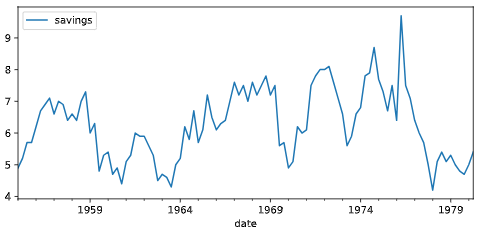

- Make a plot of the ACF, for lags 1-10 and plot it on axis ax1.
- Do the same for the PACF.

In [ ]:
# Create figure
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
 
# Plot the ACF of savings on ax1
plot_acf(savings, lags = 10, zero=False, ax=ax1)

# Plot the PACF of savings on ax2
plot_pacf(savings, lags = 10, zero=False, ax=ax2)

plt.show()

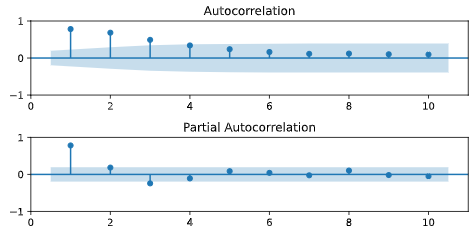

- Loop over values of p from 0 to 3 and values of q from 0 to 3.
- Inside the loop, create an ARMA(p,q) model.
- Then fit the model to the time series savings.
- At the end of each loop print the values of p and q and the AIC and BIC.

In [ ]:
# Loop over p values from 0-3
for p in range(4):
  
  # Loop over q values from 0-3
    for q in range(4):
      try:
        # Create and fit ARMA(p,q) model
        model = ARIMA(savings, order=(p,0,q))
        results = model.fit()
        
        # Print p, q, AIC, BIC
        print(p, q, results.aic, results.bic)
        
      except:
        print(p, q, None, None)

    0 0 313.6028657381061 318.85281136467466
    0 1 267.06970980844704 274.94462824829986
    0 2 232.16782677363798 242.66771802677508
    0 3 217.59720509753365 230.72206916395498
    1 0 216.203479563773 224.0783980036258
    1 1 215.7003889529165 226.2002802060536
    1 2 207.6529838444748 220.77784791089613
    1 3 209.57498315813876 225.3248200378444
    2 0 213.97232199692382 224.47221325006092
    2 1 213.4303586787578 226.55522274517915
    2 2 209.57903144324032 225.32886832294594
    2 3 211.57498195187546 229.94979164486534
    3 0 209.54492936717307 222.6697934335944
    3 1 210.82147284903212 226.57130972873773
    3 2 211.45759548497693 229.83240517796682
    3 3 213.35650857579535 234.3562910820695

### Diagnostics
You have arrived at the model diagnostic stage. So far you have found that the initial time series was stationary, but may have one outlying point. You identified promising model orders using the ACF and PACF and confirmed these insights by training a lot of models and using the AIC and BIC.

You found that the ARMA(1,2) model was the best fit to our data and now you want to check over the predictions it makes before you would move it into production.

The time series savings has been loaded and the ARIMA class has been imported into your environment.

- Retrain the ARMA(1,2) model on the time series, setting the trend to constant.
- Create the 4 standard diagnostics plots.
- Print the model residual summary statistics.

In [ ]:
# Create and fit model
model = ARIMA(savings, order=(1,0,2))
results = model.fit()

# Create the 4 diagostics plots
results.plot_diagnostics
plt.show()

# Print summary
print(results.summary())
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                savings   No. Observations:                  102
Model:                 ARIMA(1, 0, 2)   Log Likelihood                 -98.826
Date:                Fri, 24 Jan 2025   AIC                            207.653
Time:                        04:40:57   BIC                            220.778
Sample:                    01-01-1955   HQIC                           212.968
                         - 04-01-1980                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.1949      0.323     19.169      0.000       5.561       6.828
ar.L1          0.7284      0.111      6.534      0.000       0.510       0.947
ma.L1         -0.0538      0.145     -0.370      0.711      -0.338       0.231
ma.L2          0.3681      0.097      3.814      0.000       0.179       0.557
sigma2         0.4012      0.043      9.264      0.000       0.316       0.486
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                55.12
Prob(Q):                              0.89   Prob(JB):                         0.00
Heteroskedasticity (H):               2.61   Skew:                             0.82
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).


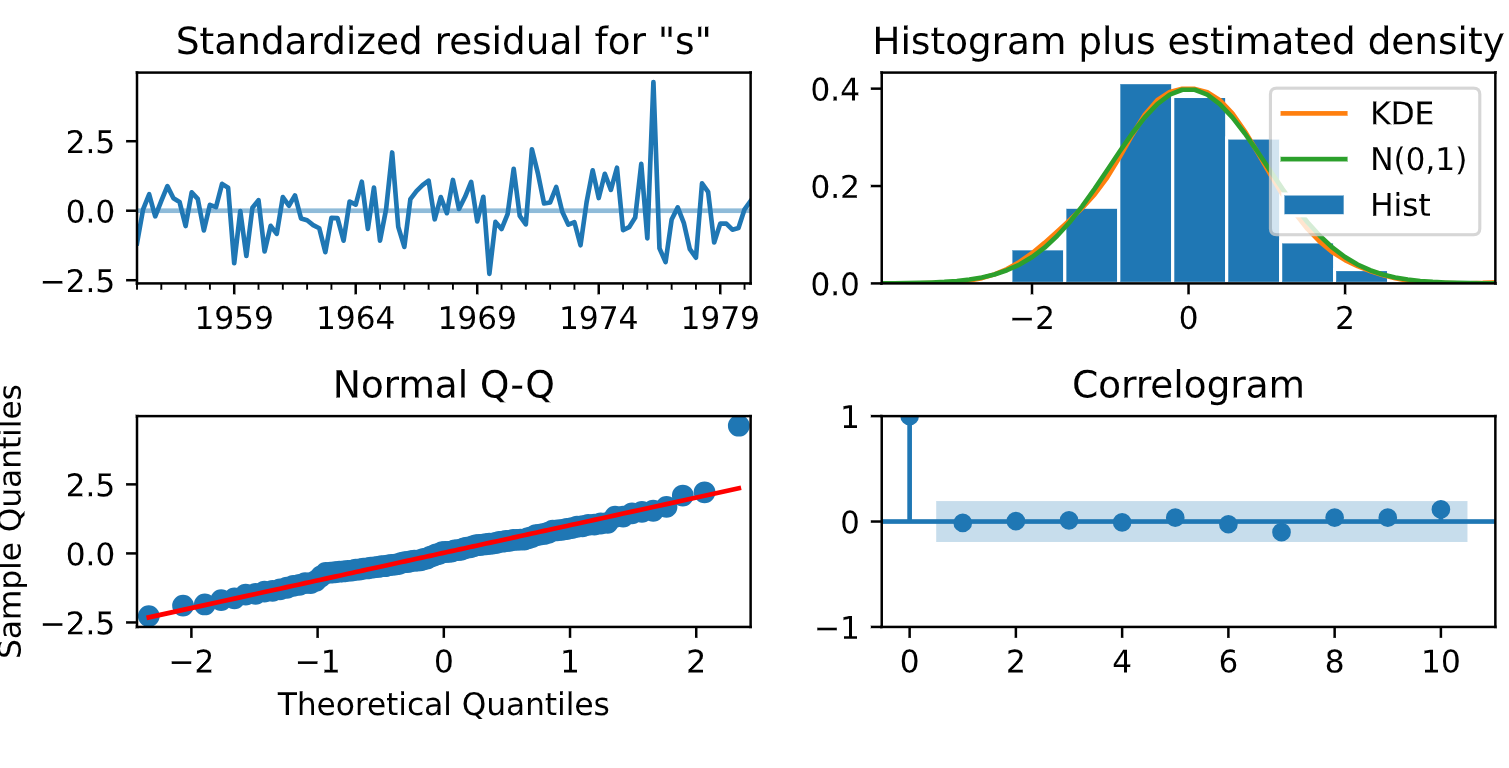

Great! The JB p-value is zero, which means you should reject the null hypothesis that the residuals are normally distributed. However, the histogram and Q-Q plots show that the residuals look normal. This time the JB value was thrown off by the one outlying point in the time series. In this case, you could go back and apply some transformation to remove this outlier or you probably just continue to the production stage.